In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:

# Load the dataset
#df = pd.read_csv("/Users/anandguntuku/Movies/VSCodeFolder/SarvaniMLOps/Data/dfx1_on_jul21_.csv")
df = pd.read_csv("/Users/anandguntuku/Movies/VSCodeFolder/SarvaniMLOps/Data/dfx1_of_jul21_.csv")
df

,Unnamed: 0,Outlet,Date_Time,Bill_No,Item_Name,Item_Category,Item_Price,Item_Quantity,Item_Total_Amount,Bill_Item_Count,Order_Type,Weekday,Total_Bill_Amount_Corrected,Daily_Bill_Amount,Corrected_Item_Name,Portion_Code,Corrected_Item_Category,total_weight_kg,Festivity,Bill_Class
0,33,MADDILAPALEM OUTLET,2022-04-01 06:54:17.779,2022211,KOVA BISCUITS (ORANGE),KOVA SWEETS,266.6667,1.0,279.9967,1,general,4,280.0,209884.0,KOVABISCUITS(ORANGE)0500G,0500G,KOVA SWEETS0500G,0.50,regular,Small
1,34,MADDILAPALEM OUTLET,2022-04-01 08:27:52.593,2022212,MOTHICHOOR LADDU RED,LADDUS,180.9524,1.0,190.0024,1,general,4,190.0,209884.0,MOTHICHOORLADDURED0500G,0500G,LADDUS0500G,0.50,regular,Micro
2,35,MADDILAPALEM OUTLET,2022-04-01 08:56:43.153,2022213,BELLAM PUTHAREKULU,HOME FOODS,128.5714,2.0,270.0029,2,general,4,385.0,209884.0,BELLAMPUTHAREKULU0250G,0250G,HOME FOODS0250G,0.50,regular,Small
3,36,MADDILAPALEM OUTLET,2022-04-01 08:56:43.158,2022213,CHAMCHAM,BENGALI SYRUP ITEMS,109.5238,1.0,115.0038,2,general,4,385.0,209884.0,CHAMCHAM0250G,0250G,BENGALI SYRUP ITEMS0250G,0.25,regular,Small
4,44,MADDILAPALEM OUTLET,2022-04-01 11:01:31.613,2022218,BOBBATLU,HOME FOODS,90.4762,1.0,94.9962,3,general,4,285.0,209884.0,BOBBATLU0250G,0250G,HOME FOODS0250G,0.25,regular,Small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6407262,8607990,EENADU OUTLET,2024-03-31 21:29:16.085,202313116362,BOBBATLU,HOME FOODS,100.0000,1.0,105.0000,1,general,6,105.0,390960.0,BOBBATLU0250G,0250G,HOME FOODS0250G,0.25,regular,Micro
6407263,8607991,EENADU OUTLET,2024-03-31 21:41:28.865,202313116363,KAJA OIL,MAIDHA SWEETS,361.9048,1.0,380.0048,2,general,6,418.0,390960.0,KAJAOIL1000G,1000G,MAIDHA SWEETS1000G,1.00,regular,Small
6407264,8607992,EENADU OUTLET,2024-03-31 21:41:28.915,202313116363,WHITE KALAKAND,KALAKANDS,36.1905,1.0,38.0005,2,general,6,418.0,390960.0,WHITEKALAKAND0050G,0050G,KALAKANDS0050G,0.05,regular,Small
6407265,8607993,EENADU OUTLET,2024-03-31 21:52:28.906,202313116364,KAJA GHEE,MAIDHA SWEETS,138.0952,1.0,144.9952,2,general,6,335.0,390960.0,KAJAGHEE0250G,0250G,MAIDHA SWEETS0250G,0.25,regular,Small


In [15]:
df[df['total_weight_kg'].isna() != True]

,Unnamed: 0,Outlet,Date_Time,Bill_No,Item_Name,Item_Category,Item_Price,Item_Quantity,Item_Total_Amount,Bill_Item_Count,Order_Type,Weekday,Total_Bill_Amount_Corrected,Daily_Bill_Amount,Corrected_Item_Name,Portion_Code,Corrected_Item_Category,total_weight_kg,Festivity,Bill_Class
0,33,MADDILAPALEM OUTLET,2022-04-01 06:54:17.779,2022211,KOVA BISCUITS (ORANGE),KOVA SWEETS,266.6667,1.0,279.9967,1,general,4,280.0,209884.0,KOVABISCUITS(ORANGE)0500G,0500G,KOVA SWEETS0500G,0.50,regular,Small
1,34,MADDILAPALEM OUTLET,2022-04-01 08:27:52.593,2022212,MOTHICHOOR LADDU RED,LADDUS,180.9524,1.0,190.0024,1,general,4,190.0,209884.0,MOTHICHOORLADDURED0500G,0500G,LADDUS0500G,0.50,regular,Micro
2,35,MADDILAPALEM OUTLET,2022-04-01 08:56:43.153,2022213,BELLAM PUTHAREKULU,HOME FOODS,128.5714,2.0,270.0029,2,general,4,385.0,209884.0,BELLAMPUTHAREKULU0250G,0250G,HOME FOODS0250G,0.50,regular,Small
3,36,MADDILAPALEM OUTLET,2022-04-01 08:56:43.158,2022213,CHAMCHAM,BENGALI SYRUP ITEMS,109.5238,1.0,115.0038,2,general,4,385.0,209884.0,CHAMCHAM0250G,0250G,BENGALI SYRUP ITEMS0250G,0.25,regular,Small
4,44,MADDILAPALEM OUTLET,2022-04-01 11:01:31.613,2022218,BOBBATLU,HOME FOODS,90.4762,1.0,94.9962,3,general,4,285.0,209884.0,BOBBATLU0250G,0250G,HOME FOODS0250G,0.25,regular,Small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6407262,8607990,EENADU OUTLET,2024-03-31 21:29:16.085,202313116362,BOBBATLU,HOME FOODS,100.0000,1.0,105.0000,1,general,6,105.0,390960.0,BOBBATLU0250G,0250G,HOME FOODS0250G,0.25,regular,Micro
6407263,8607991,EENADU OUTLET,2024-03-31 21:41:28.865,202313116363,KAJA OIL,MAIDHA SWEETS,361.9048,1.0,380.0048,2,general,6,418.0,390960.0,KAJAOIL1000G,1000G,MAIDHA SWEETS1000G,1.00,regular,Small
6407264,8607992,EENADU OUTLET,2024-03-31 21:41:28.915,202313116363,WHITE KALAKAND,KALAKANDS,36.1905,1.0,38.0005,2,general,6,418.0,390960.0,WHITEKALAKAND0050G,0050G,KALAKANDS0050G,0.05,regular,Small
6407265,8607993,EENADU OUTLET,2024-03-31 21:52:28.906,202313116364,KAJA GHEE,MAIDHA SWEETS,138.0952,1.0,144.9952,2,general,6,335.0,390960.0,KAJAGHEE0250G,0250G,MAIDHA SWEETS0250G,0.25,regular,Small


In [9]:
df['Bill_Item_Count'].value_counts()

Bill_Item_Count
1     1710017
2     1700589
3     1209011
4      751544
5      439227
6      253258
7      142748
8       81240
9       47646
10      27931
11      16918
12      10404
13       5772
14       4004
15       2370
16       1552
17        867
18        666
19        323
20        260
21        252
22        176
27        135
23        115
28         84
26         52
39         39
37         37
30         30
Name: count, dtype: int64

In [3]:
df.columns

Index(['Unnamed: 0', 'Outlet', 'Date_Time', 'Bill_No', 'Item_Name',
       'Item_Category', 'Item_Price', 'Item_Quantity', 'Item_Total_Amount',
       'Bill_Item_Count', 'Order_Type', 'Weekday',
       'Total_Bill_Amount_Corrected', 'Daily_Bill_Amount',
       'Corrected_Item_Name', 'Portion_Code', 'Corrected_Item_Category',
       'total_weight_kg', 'Festivity', 'Bill_Class'],
      dtype='object')

In [65]:
def change_datetime(df):
    df['Date_Time'] = pd.to_datetime(df['Date_Time'])
    return df
df = change_datetime(df)

In [66]:
def revenue(df):
    rev = df[['Date_Time', 'Item_Total_Amount']]
    rev_daily = rev.groupby(df['Date_Time'].dt.date)['Item_Total_Amount'].sum().reset_index()
    return rev_daily

rev_daily = revenue(df)
rev_daily


,Date_Time,Item_Total_Amount
0,2021-07-01,9.925882e+05
1,2021-07-02,7.598968e+05
2,2021-07-03,9.522170e+05
3,2021-07-04,9.750427e+05
4,2021-07-05,7.282254e+05
...,...,...
1278,2024-12-30,1.179408e+06
1279,2024-12-31,5.298408e+06
1280,2025-01-01,4.035719e+06
1281,2025-01-02,1.333908e+06


In [67]:

# Apply classical seasonal decomposition
result = seasonal_decompose(series, model='additive', period=365)
result

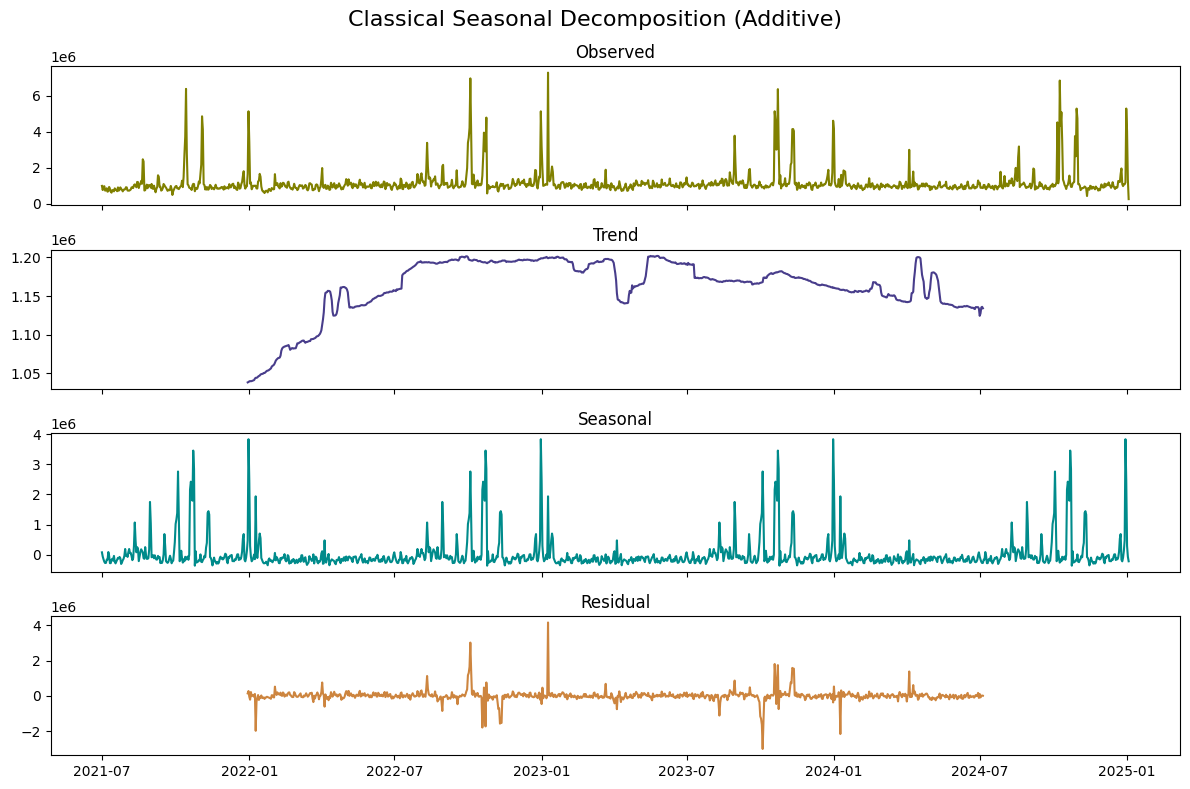

In [68]:
# Plot with custom colors
fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axs[0].plot(result.observed, color='olive')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='darkslateblue')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkcyan')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='peru')
axs[3].set_title('Residual')

plt.suptitle('Classical Seasonal Decomposition (Additive)', fontsize=16)
plt.tight_layout()
plt.show()

STL DECOMPOSITION TECHNIQUE

In [55]:
from statsmodels.tsa.seasonal import STL

In [83]:
rev_daily.reset_index(inplace=True)
rev_daily['Date_Time'] = pd.to_datetime(rev_daily['Date_Time'])
rev_daily.set_index('Date_Time', inplace=True)
# Extract the series
series_stl = rev_daily['Item_Total_Amount']

In [84]:
import pickle
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA

class STLForecastPipeline:
    def __init__(self, seasonal_period=365, arima_order=(1,1,1)):
        self.seasonal_period = seasonal_period
        self.arima_order = arima_order
        self.stl_result = None
        self.model = None
        self.model_fit = None
        self.seasonal_component = None

    def fit(self, series):
        # Decompose series
        stl = STL(series, seasonal=self.seasonal_period)
        self.stl_result = stl.fit()

        # Store the seasonal component
        self.seasonal_component = self.stl_result.seasonal

        # Fit ARIMA to the deseasonalized series
        deseasonalized = series - self.seasonal_component
        self.model = ARIMA(deseasonalized, order=self.arima_order)
        self.model_fit = self.model.fit()

    def forecast(self, steps):
        # Forecast trend + residual
        forecast_deseasonalized = self.model_fit.forecast(steps)

        # Repeat seasonal pattern
        seasonal_cycle = self.seasonal_component[-self.seasonal_period:]
        seasonal_forecast = np.resize(seasonal_cycle, steps)

        # Final forecast = trend+residual + seasonal
        return forecast_deseasonalized + seasonal_forecast


In [96]:
# Create and fit the model
pipeline = STLForecastPipeline(seasonal_period=33)
pipeline.fit(series_stl)  # `series` is your daily sales time series

# Save entire pipeline
with open('stl_forecast_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)


/Users/anandguntuku/Movies/VSCodeFolder/SarvaniMLOps/venv-311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/anandguntuku/Movies/VSCodeFolder/SarvaniMLOps/venv-311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/anandguntuku/Movies/VSCodeFolder/SarvaniMLOps/venv-311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [86]:
# Load later
with open('stl_forecast_pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

# Predict next 180 days
forecast = loaded_pipeline.forecast(180)

In [95]:
import json
#rev_daily.reset_index(inplace=True)
columns = rev_daily.columns.tolist()
print(columns)
json_str = json.dumps(columns)

# ✅ Save to file using json.dump()

output_path = '/Users/anandguntuku/Movies/VSCodeFolder/SarvaniMLOps/outputs/server/artifacts/output.json'

with open(output_path, 'w') as f:
    json.dump(columns, f, indent=4)

['level_0', 'Date_Time', 'index', 'Item_Total_Amount']
